# <span style = "color: green">Simple Linear Regression<span>

***

In this example, we will consider sales based on 'TV' marketing budget.<br>
We'll build a linear regression model to predict 'Sales' using 'TV' as the predictor variable.

### Understanding the data

#### Import pandas

In [1]:
import pandas as pd

#### Read the dataset with pandas

In [2]:
df = pd.read_csv('tvmarketing.csv') 
df = df[['TV', 'Sales']]

#### View the first five rows of the dataset

In [3]:
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


#### View the last 5 rows

In [4]:
df.tail()

,TV,Sales
195,38.2,7.6
196,94.2,9.7
197,177.0,12.8
198,283.6,25.5
199,232.1,13.4


#### Check info about the dataset

In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


#### Check the number of rows and columns in the dataset

In [6]:
df.shape

(200, 2)

#### Quick view the basic statistical information about the dataset

In [7]:
df.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


## Visualising the data using Seaborn Library

#### Import Matplotlib, Seaborn and set matplotlib inline

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#### Visualize the relationship between the features and the response using scatterplots

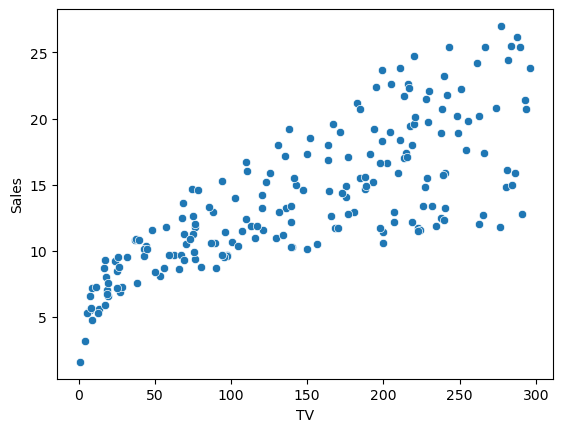

In [11]:
sns.scatterplot(data=df, x='TV', y='Sales')
plt.show()

## Performing Simple Linear Regression

Equation of linear regression<br>
$y = c + m_1x_1 + m_2x_2 + ... + m_nx_n$

-  $y$ is the response
-  $c$ is the intercept
-  $m_1$ is the coefficient for the first feature
-  $m_n$ is the coefficient for the nth feature<br>

In our case:

$y = c + m_1 \times TV$

The $m$ values are called the model **coefficients** or **model parameters**.

### Generic Steps in Model Building using ```sklearn```

Before you read further, it is good to understand the generic structure of modeling using the scikit-learn library. Broadly, the steps to build any model can be divided as follows: 

### Preparing X and y (Independent and Dependent variables)
-  The scikit-learn library expects X (feature variable) and y (response variable) to be NumPy arrays.
-  However, X can be a dataframe as Pandas is built over NumPy.

#### Assign feature variable(Independent variable) to X

In [13]:
X = df[['TV']]

#### Print the first five rows of X

In [14]:
X.head()

,TV
0,230.1
1,44.5
2,17.2
3,151.5
4,180.8


#### Assign response variable(Dependent variable or target variable) to y

In [16]:
y=df['Sales']

#### Split the data into Training and testing Sets

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size = 0.3, random_state = 100)

In [14]:
# random_state is the seed used by the random number generator, it can be any integer.
# If we don't specify a random state integer, we get different training and test data every time we run the code

In [18]:
train_test_split   #Press Tab to auto-fill the code
#Press Tab+Shift to read the documentationy

<function sklearn.model_selection._split.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)>

#### Check the shape of training and testing set

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(140, 1)
(60, 1)
(140,)
(60,)


### Performing Linear Regression

#### Import LinearRegression from sklearn linear model

In [21]:
from sklearn.linear_model import LinearRegression

#### Create a LinearRegression object

In [22]:
lr = LinearRegression()

#### Train the model (lr) using fit 

In [23]:
lr.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Print the coefficient and Intercept 

In [25]:
print(lr.coef_)
print(lr.intercept_)

[0.04649736]
6.989665857411681


#### Check the score of our model

In [26]:
lr.score(X_train, y_train)
lr.score(X_test, y_test)

0.5942987267783302

### Make predictions on the testing set

In [28]:
y_pred = lr.predict(X_test)

### Plot a graph to check the accuracy of our prediction

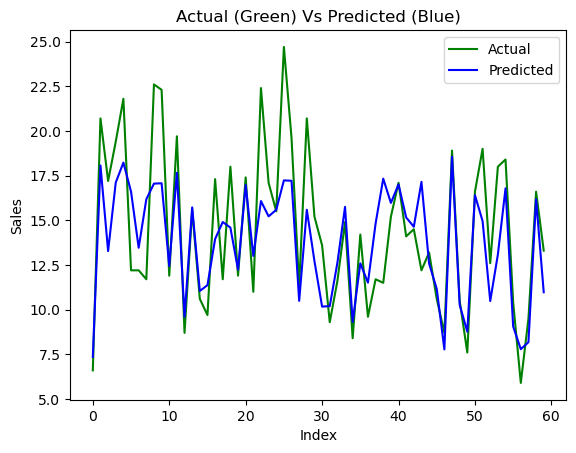

In [29]:
plt.plot(y_test.values, label='Actual', color='green')
plt.plot(y_pred, label='Predicted', color='blue')
plt.title('Actual (Green) Vs Predicted (Blue)')
plt.xlabel('Index')
plt.ylabel('Sales')
plt.legend()
plt.show()

### Plot a scatterplot of actual values vs predicted

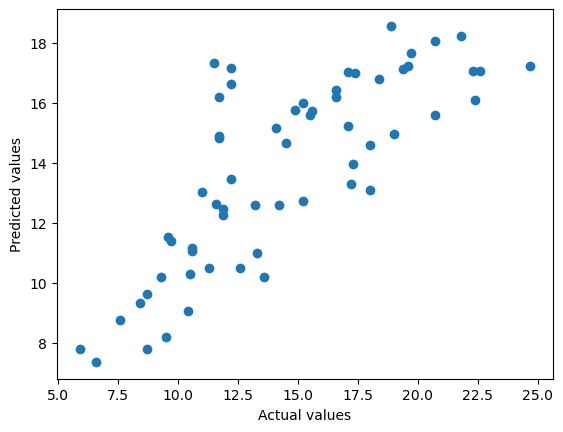

In [30]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.show()

### Calculate mean squared error and r2_score

Mean Squared Error:It is the sum, over all the data points, of the square of the difference between the predicted and actual target variables, divided by the number of data points.

y-ypred<sup>2<sup>
    
$$e_i= YPred-Yi$$ 
$$Y pred= mx+c$$
i.e, $$e_1=((m_i*x+c)-y_i)$$
    
i.e, $$e_1^2=(y_1 - (m_i*x+c))^2$$

#### Import mean_squared_error and r2_score from sklearn.metrics

In [31]:
from sklearn.metrics import mean_squared_error, r2_score

#### Calculate the mean squared error

In [32]:
mse = mean_squared_error(y_test, y_pred)
print(mse)

7.975798532854849


#### Calculate r2_score

0.5942987267783302

***